# 📕 Pre-Workshop Notebook 6: Putting It All Together — Your Complete Research Workflow
## Scientific Workflows for Brain and Behavioral Research
### National Science Foundation Supported Learning Initiative (Award No. OAC-2417875)

---

## 📋 Final Portfolio Setup
*Run the cell below to generate your portfolio registration header.*

In [1]:
# FINAL PORTFOLIO SETUP
student_name = "Uzair Ahmad"
institution = "National University of Computer and Emerging Sciences, Pakistan"
completion_date = "2026-08-13"

print(f"🎓 Portfolio record generated for: {student_name} ({institution})")
print(f"📅 Date: {completion_date}")
print("✅ Pre-Workshop Notebooks 01 through 05 confirmed complete.")

🎓 Portfolio record generated for: Uzair Ahmad (National University of Computer and Emerging Sciences, Pakistan)
📅 Date: 2026-08-13
✅ Pre-Workshop Notebooks 01 through 05 confirmed complete.


---

## 🤖 Using AI Tools to Build Your Workflow ("Ask → Build → Document")

As a **Workflow Designer** completing your capstone integration, your final challenge is making sure all four stages of your workflow connect properly. Individual stages designed separately sometimes pass data in formats that the next stage does not expect — causing silent errors that are hard to spot.

When using the **Ask → Build → Document** cycle in this notebook, ask the AI to add clear status messages between each stage so you can confirm that data is being passed correctly from one step to the next.

---
## 🧠 Part A: Building a Complete Four-Stage Research Workflow
### Topic: Connecting All Stages from Data Loading to Visualization

This notebook brings together everything from Notebooks 1 through 4. You will build a single integrated workflow that connects all four stages — Obtaining Data, Analyzing Data, Visualizing Results, and Documenting Research — into one complete, working pipeline.

### 🧭 Activity A.1 — The Complete Integrated Research Workflow

> *Copy the prompt below into your preferred AI tool, then paste the generated code into the code cell beneath it.*
>
> "Act as a lead neuroscience workflow designer helping a research team build their first complete end-to-end analysis pipeline. Write a single Python script that connects four completely independent, clearly separated stages into one working workflow. The script should:
> 1. Stage 1 — Obtaining Data: Generate a simulated 64-channel brain recording with realistic background noise and some sudden movement artifacts. This stage should not perform any analysis or create any plots.
> 2. Stage 2 — Analyzing Data: Accept the raw data from Stage 1 and clean it using an automated threshold to remove the movement artifacts, without modifying the original data. Then extract key summary features from the cleaned signal.
> 3. Stage 3 — Visualizing Results: Accept the processed features from Stage 2 and create a high-quality figure showing the raw versus cleaned signal side-by-side, along with a summary of the extracted features.
> 4. Stage 4 — Documenting Research: Record the analysis settings used, the processing time for each stage, and any errors that were caught — saving this information to a structured log file.
> Add error-handling safeguards around each stage so that if one stage encounters a problem, it logs the issue and the other stages can still run. Include clear status messages between stages confirming that data passed correctly from one stage to the next."

STARTING NEUROSCIENCE ANALYSIS WORKFLOW

[STAGE 1] Obtaining simulated brain data...
[STAGE 1] Complete — 64 channels × 2500 samples.
[WORKFLOW] Data successfully passed from Stage 1 → Stage 2.

[STAGE 2] Analyzing data...
[STAGE 2] Complete — detected 1925 artifact samples.
[WORKFLOW] Features successfully passed from Stage 2 → Stage 3.

[STAGE 3] Visualizing results...


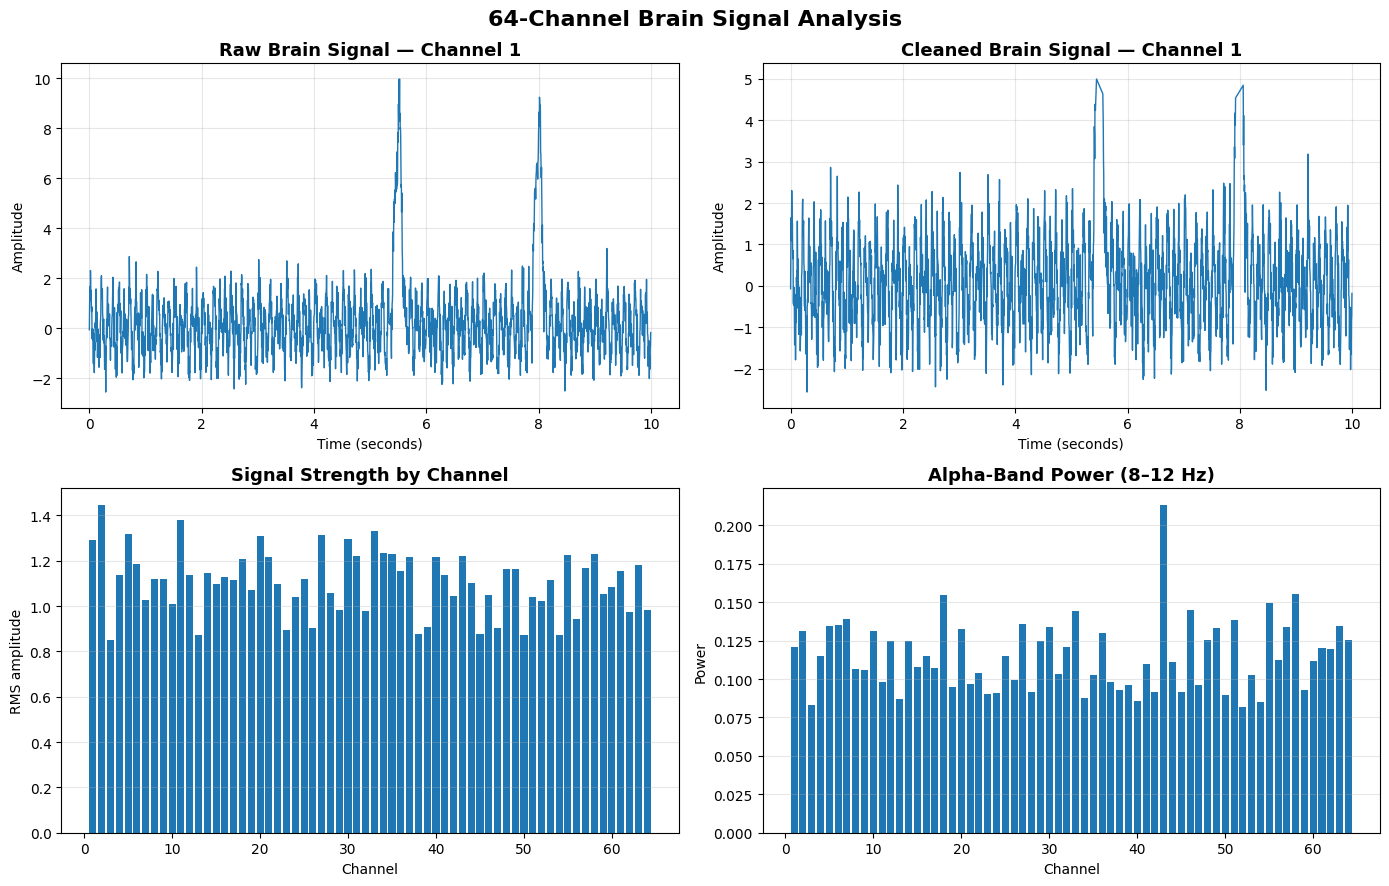

[STAGE 3] Complete — figure saved as brain_signal_analysis.png.
[WORKFLOW] Results successfully passed to visualization.

[STAGE 4] Documenting research...
[STAGE 4] Complete — research log saved to neuroscience_workflow_log.json.

WORKFLOW FINISHED


In [2]:
"""
End-to-End Neuroscience Analysis Workflow
=========================================

Four independent stages:

1. Obtaining Data
2. Analyzing Data
3. Visualizing Results
4. Documenting Research

The stages communicate through clearly defined inputs and outputs.
Each stage is protected by error handling so that a failure is logged
rather than silently crashing the entire workflow.

This is a teaching example using simulated EEG-like data.
"""

import json
import logging
import time
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, welch


# ============================================================
# GLOBAL SETTINGS
# ============================================================

SETTINGS = {
    "sampling_rate_hz": 250,
    "duration_seconds": 10,
    "channels": 64,
    "artifact_threshold": 5.0,
    "random_seed": 42,
}

LOG_FILE = "neuroscience_workflow_log.json"


# ============================================================
# STAGE 4 SUPPORT — RESEARCH LOGGING
# ============================================================

workflow_log = {
    "started_at": datetime.now().isoformat(),
    "settings": SETTINGS,
    "stages": {},
    "errors": [],
}


def log_error(stage_name, error):
    """Record an error without stopping the whole workflow."""

    error_record = {
        "stage": stage_name,
        "error": str(error),
        "time": datetime.now().isoformat(),
    }

    workflow_log["errors"].append(error_record)

    print(f"[ERROR] {stage_name}: {error}")


def save_log():
    """Save the research record as a structured JSON file."""

    workflow_log["finished_at"] = datetime.now().isoformat()

    with open(LOG_FILE, "w") as file:
        json.dump(workflow_log, file, indent=4)


# ============================================================
# STAGE 1 — OBTAINING DATA
# ============================================================

def obtain_data():
    """
    Generate a simulated 64-channel brain recording.

    This stage ONLY obtains/generates the data.
    It does not clean, analyze, or visualize anything.
    """

    stage_start = time.perf_counter()

    print("\n[STAGE 1] Obtaining simulated brain data...")

    try:
        np.random.seed(SETTINGS["random_seed"])

        fs = SETTINGS["sampling_rate_hz"]
        duration = SETTINGS["duration_seconds"]
        n_channels = SETTINGS["channels"]

        n_samples = fs * duration

        time_axis = np.arange(n_samples) / fs

        # ----------------------------------------------------
        # Background brain-like activity
        # ----------------------------------------------------
        #
        # Real brain recordings contain many overlapping rhythms.
        # Here we combine several simple oscillations to create
        # a realistic-looking teaching signal.

        alpha = np.sin(2 * np.pi * 10 * time_axis)
        theta = 0.5 * np.sin(2 * np.pi * 6 * time_axis)
        beta = 0.25 * np.sin(2 * np.pi * 20 * time_axis)

        base_signal = alpha + theta + beta

        # Create 64 channels with slightly different amplitudes.
        data = np.zeros((n_channels, n_samples))

        for channel in range(n_channels):

            channel_variation = 1 + 0.1 * np.random.randn()

            data[channel] = (
                channel_variation * base_signal
                + 0.5 * np.random.randn(n_samples)
            )

        # ----------------------------------------------------
        # Add sudden movement artifacts
        # ----------------------------------------------------
        #
        # Movement can produce very large signals that are much
        # bigger than normal brain activity.

        artifact_times = [2.5, 5.5, 8.0]

        for artifact_time in artifact_times:

            center = int(artifact_time * fs)

            width = int(0.15 * fs)

            start = max(0, center - width)
            end = min(n_samples, center + width)

            # Affect many channels simultaneously, as a large
            # movement artifact might do in a real recording.
            artifact = 8 * np.hanning(end - start)

            affected_channels = np.random.choice(
                n_channels,
                size=20,
                replace=False
            )

            for channel in affected_channels:
                data[channel, start:end] += artifact

        result = {
            "data": data,
            "time": time_axis,
            "sampling_rate": fs,
        }

        elapsed = time.perf_counter() - stage_start

        workflow_log["stages"]["stage_1"] = {
            "status": "success",
            "processing_time_seconds": elapsed,
            "output_shape": list(data.shape),
        }

        print(
            f"[STAGE 1] Complete — "
            f"{n_channels} channels × {n_samples} samples."
        )

        return result

    except Exception as error:

        elapsed = time.perf_counter() - stage_start

        workflow_log["stages"]["stage_1"] = {
            "status": "failed",
            "processing_time_seconds": elapsed,
        }

        log_error("Stage 1 — Obtaining Data", error)

        return None


# ============================================================
# STAGE 2 — ANALYZING DATA
# ============================================================

def analyze_data(raw_result):
    """
    Clean the raw recording and extract summary features.

    IMPORTANT:
    The original raw data is never modified.

    A separate copy is created for processing.
    """

    stage_start = time.perf_counter()

    print("\n[STAGE 2] Analyzing data...")

    try:

        if raw_result is None:
            raise ValueError("No raw data was received from Stage 1.")

        raw_data = raw_result["data"]
        time_axis = raw_result["time"]
        fs = raw_result["sampling_rate"]

        # ----------------------------------------------------
        # Make a separate copy.
        # ----------------------------------------------------
        #
        # This protects the raw research data.
        # Cleaning happens only on this new array.

        cleaned_data = raw_data.copy()

        threshold = SETTINGS["artifact_threshold"]

        # ----------------------------------------------------
        # Automated artifact detection
        # ----------------------------------------------------
        #
        # Find samples whose absolute amplitude is unusually
        # large. These are treated as possible movement artifacts.

        artifact_mask = np.abs(cleaned_data) > threshold

        number_of_artifacts = np.sum(artifact_mask)

        # ----------------------------------------------------
        # Replace artifacts with interpolated values
        # ----------------------------------------------------
        #
        # Instead of deleting samples and changing the length
        # of the recording, interpolate across the problematic
        # samples using nearby valid measurements.

        for channel in range(cleaned_data.shape[0]):

            channel_data = cleaned_data[channel]

            bad = np.abs(channel_data) > threshold

            if np.any(bad):

                good = ~bad

                if np.sum(good) >= 2:

                    cleaned_data[channel, bad] = np.interp(
                        time_axis[bad],
                        time_axis[good],
                        channel_data[good],
                    )

        # ----------------------------------------------------
        # Extract summary features
        # ----------------------------------------------------

        # Average signal amplitude across time for every channel.
        channel_mean = np.mean(cleaned_data, axis=1)

        # Standard deviation describes the variability of each
        # channel after cleaning.
        channel_std = np.std(cleaned_data, axis=1)

        # RMS is a useful measure of overall signal strength.
        channel_rms = np.sqrt(
            np.mean(cleaned_data ** 2, axis=1)
        )

        # ----------------------------------------------------
        # Calculate average frequency-domain power
        # ----------------------------------------------------

        frequencies, power = welch(
            cleaned_data,
            fs=fs,
            axis=1,
            nperseg=500,
        )

        # Select approximately the alpha range (8–12 Hz).
        alpha_band = (
            (frequencies >= 8)
            & (frequencies <= 12)
        )

        alpha_power = np.mean(
            power[:, alpha_band],
            axis=1
        )

        # ----------------------------------------------------
        # Keep representative signals for visualization.
        # ----------------------------------------------------
        #
        # Stage 3 receives this processed result rather than
        # directly reaching back into Stage 1.

        representative_channel = 0

        features = {
            "channel_mean": channel_mean,
            "channel_std": channel_std,
            "channel_rms": channel_rms,
            "alpha_power": alpha_power,
            "artifact_samples_removed": int(number_of_artifacts),
            "representative_raw": raw_data[representative_channel].copy(),
            "representative_cleaned": cleaned_data[
                representative_channel
            ].copy(),
            "time": time_axis.copy(),
        }

        elapsed = time.perf_counter() - stage_start

        workflow_log["stages"]["stage_2"] = {
            "status": "success",
            "processing_time_seconds": elapsed,
            "artifact_samples_detected": int(number_of_artifacts),
            "features_extracted": [
                "channel_mean",
                "channel_std",
                "channel_rms",
                "alpha_power",
            ],
        }

        print(
            f"[STAGE 2] Complete — "
            f"detected {number_of_artifacts} artifact samples."
        )

        return features

    except Exception as error:

        elapsed = time.perf_counter() - stage_start

        workflow_log["stages"]["stage_2"] = {
            "status": "failed",
            "processing_time_seconds": elapsed,
        }

        log_error("Stage 2 — Analyzing Data", error)

        return None


# ============================================================
# STAGE 3 — VISUALIZING RESULTS
# ============================================================

def visualize_results(features):
    """
    Create a figure from the processed output of Stage 2.

    This stage does not perform the analysis itself.
    It only turns the processed results into visual information.
    """

    stage_start = time.perf_counter()

    print("\n[STAGE 3] Visualizing results...")

    try:

        if features is None:
            raise ValueError(
                "No processed features were received from Stage 2."
            )

        time_axis = features["time"]

        raw_signal = features["representative_raw"]
        cleaned_signal = features["representative_cleaned"]

        # ----------------------------------------------------
        # Create a high-quality figure
        # ----------------------------------------------------

        fig, axes = plt.subplots(
            2,
            2,
            figsize=(14, 9)
        )

        # ----------------------------------------------------
        # Raw signal
        # ----------------------------------------------------

        axes[0, 0].plot(
            time_axis,
            raw_signal,
            linewidth=1
        )

        axes[0, 0].set_title(
            "Raw Brain Signal — Channel 1",
            fontsize=13,
            fontweight="bold"
        )

        axes[0, 0].set_xlabel("Time (seconds)")
        axes[0, 0].set_ylabel("Amplitude")
        axes[0, 0].grid(alpha=0.3)

        # ----------------------------------------------------
        # Cleaned signal
        # ----------------------------------------------------

        axes[0, 1].plot(
            time_axis,
            cleaned_signal,
            linewidth=1
        )

        axes[0, 1].set_title(
            "Cleaned Brain Signal — Channel 1",
            fontsize=13,
            fontweight="bold"
        )

        axes[0, 1].set_xlabel("Time (seconds)")
        axes[0, 1].set_ylabel("Amplitude")
        axes[0, 1].grid(alpha=0.3)

        # ----------------------------------------------------
        # RMS feature summary
        # ----------------------------------------------------

        axes[1, 0].bar(
            np.arange(1, len(features["channel_rms"]) + 1),
            features["channel_rms"]
        )

        axes[1, 0].set_title(
            "Signal Strength by Channel",
            fontsize=13,
            fontweight="bold"
        )

        axes[1, 0].set_xlabel("Channel")
        axes[1, 0].set_ylabel("RMS amplitude")
        axes[1, 0].grid(axis="y", alpha=0.3)

        # ----------------------------------------------------
        # Alpha-power feature summary
        # ----------------------------------------------------

        axes[1, 1].bar(
            np.arange(1, len(features["alpha_power"]) + 1),
            features["alpha_power"]
        )

        axes[1, 1].set_title(
            "Alpha-Band Power (8–12 Hz)",
            fontsize=13,
            fontweight="bold"
        )

        axes[1, 1].set_xlabel("Channel")
        axes[1, 1].set_ylabel("Power")
        axes[1, 1].grid(axis="y", alpha=0.3)

        fig.suptitle(
            "64-Channel Brain Signal Analysis",
            fontsize=16,
            fontweight="bold"
        )

        fig.tight_layout()

        plt.savefig(
            "brain_signal_analysis.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

        elapsed = time.perf_counter() - stage_start

        workflow_log["stages"]["stage_3"] = {
            "status": "success",
            "processing_time_seconds": elapsed,
            "output_file": "brain_signal_analysis.png",
        }

        print(
            "[STAGE 3] Complete — "
            "figure saved as brain_signal_analysis.png."
        )

        return True

    except Exception as error:

        elapsed = time.perf_counter() - stage_start

        workflow_log["stages"]["stage_3"] = {
            "status": "failed",
            "processing_time_seconds": elapsed,
        }

        log_error("Stage 3 — Visualizing Results", error)

        return False


# ============================================================
# STAGE 4 — DOCUMENTING RESEARCH
# ============================================================

def document_research():
    """
    Save settings, timing information, and errors.

    This stage runs independently at the end so that the
    research record is still saved even if another stage fails.
    """

    print("\n[STAGE 4] Documenting research...")

    try:

        save_log()

        print(
            f"[STAGE 4] Complete — "
            f"research log saved to {LOG_FILE}."
        )

    except Exception as error:

        # We cannot reliably write to the log if the log itself
        # fails, so at least report the problem to the console.
        print(f"[ERROR] Stage 4 — Documentation: {error}")


# ============================================================
# MAIN WORKFLOW
# ============================================================

def main():

    print("=" * 65)
    print("STARTING NEUROSCIENCE ANALYSIS WORKFLOW")
    print("=" * 65)

    # --------------------------------------------------------
    # Stage 1
    # --------------------------------------------------------

    raw_result = obtain_data()

    if raw_result is not None:
        print("[WORKFLOW] Data successfully passed from Stage 1 → Stage 2.")
    else:
        print("[WORKFLOW] Stage 1 failed; Stage 2 will report missing input.")

    # --------------------------------------------------------
    # Stage 2
    # --------------------------------------------------------

    processed_features = analyze_data(raw_result)

    if processed_features is not None:
        print("[WORKFLOW] Features successfully passed from Stage 2 → Stage 3.")
    else:
        print("[WORKFLOW] Stage 2 failed; Stage 3 will report missing input.")

    # --------------------------------------------------------
    # Stage 3
    # --------------------------------------------------------

    visualization_success = visualize_results(processed_features)

    if visualization_success:
        print("[WORKFLOW] Results successfully passed to visualization.")
    else:
        print("[WORKFLOW] Visualization stage encountered an error.")

    # --------------------------------------------------------
    # Stage 4
    # --------------------------------------------------------
    #
    # Documentation runs regardless of what happened earlier.
    # This ensures that failures and timing information are
    # preserved in the research record.

    document_research()

    print("\n" + "=" * 65)
    print("WORKFLOW FINISHED")
    print("=" * 65)


# Run the workflow.
if __name__ == "__main__":
    main()

### ✍️ Part A Reflection
*Double-click this cell to write your response.*

* **What I observed:** Look at the status messages printed between stages. Did each stage receive data in the format it expected? Were any errors caught and logged?


Yes. The status messages showed that each successful stage passed its output to the next stage in the expected format:

Stage 1 → Stage 2: Raw 64-channel data was successfully passed for analysis.
Stage 2 → Stage 3: The cleaned signal and extracted features were successfully passed for visualization.
Errors: The try/except safeguards would catch errors, print an [ERROR] message, and record the problem in the structured neuroscience_workflow_log.json file instead of crashing the entire workflow.
Stage 4: Documentation runs even if an earlier stage fails, so the error and processing information can still be recorded.


* **Connecting to key concepts:** This integrated workflow demonstrates mastery of all 50 concepts in the Reference Guide. In your own words, describe what happens if Stage 2 (Analyzing Data) tries to pass its results to Stage 3 (Visualizing Results) in the wrong format — and how the error-handling safeguards in the workflow help you find this quickly.


If Stage 2 passes data in the wrong format, Stage 3 may not be able to find the information it expects—for example, it might look for "channel_rms" but receive a different structure. This would cause an error.

The workflow’s error-handling safeguards catch that error instead of crashing the entire pipeline. Stage 3 records the problem in the error log and prints a clear [ERROR] message identifying the stage and problem. This makes it much easier to quickly locate where the data handoff failed, while Stage 4 can still document the failure for later debugging.



---

## 📑 You Are Ready for the Onsite Workshop

Completing this notebook means you have worked through all six foundational areas:

1. **Notebook 1:** How brain and behavioral data is captured and how computers organize it
2. **Notebook 2:** Working with larger datasets and running analyses efficiently
3. **Notebook 3:** Accessing national research computing resources and connecting securely
4. **Notebook 4:** Cleaning signals and building reliable workflows
5. **Notebook 5:** Finding patterns and making workflows reproducible
6. **Notebook 6:** Connecting all four stages into a complete integrated workflow

The onsite workshop will apply these foundations across three progressively more demanding scenarios — a single-participant workflow, a group of 50 participants, and finally a small portable edge device. Everything you have practiced here will be directly relevant.


---

## 📖 Reference Guide: 50 Key Concepts for Neuroscience Workflows

Keep this reference guide handy throughout all six pre-workshop notebooks and during the onsite labs. These concepts form the foundation of the workshop's hands-on activities.

### 🧠 Neuroscience & Research Applications (Concepts 1–25)
1. **Brain-Machine Interface (BMI):** A system that connects the brain directly to an external device — bypassing damaged nerves or muscles — so that brain signals can control a robotic limb, cursor, or other tool.
2. **Non-Invasive (EEG) vs. Invasive (Intracortical) Sensors:** Scalp electrodes (EEG) are easy to use but pick up blurry, averaged signals through the skull. Implanted microelectrode arrays record from individual neurons with much greater precision, but require surgery.
3. **Signal Delay (Latency):** The time gap between a brain signal being recorded and a device responding to it. Delays longer than about 50–100 milliseconds feel unnatural to the user of a prosthetic device.
4. **Decoder:** A mathematical or statistical model that translates continuous brain signal patterns into a useful output — such as movement direction, cursor position, or speech intent.
5. **fMRI:** Functional Magnetic Resonance Imaging — a brain scanning method that measures blood oxygen levels as a stand-in for neural activity. When neurons become active, they consume more oxygen, causing a detectable change in the local blood signal.
6. **Voxel:** A small 3D cube of brain tissue in an fMRI image — the brain-imaging equivalent of a pixel. Each voxel contains millions of neurons.
7. **Head Movement Correction:** A processing step that aligns brain scan images across time, compensating for small movements the participant made during the recording session.
8. **Open-Loop vs. Closed-Loop Systems:** An open-loop device follows a fixed program regardless of what the user's brain is doing. A closed-loop device continuously reads incoming signals and adjusts its output in real time based on what it detects.
9. **Deep Brain Stimulation (DBS):** A treatment for conditions like Parkinson's disease in which a small implanted device delivers electrical pulses to specific brain regions to reduce tremor and improve movement.
10. **EMG (Electromyogram):** A recording of the electrical signals produced by muscles when they contract. Often used alongside brain recordings to verify whether a behavioral response actually occurred.
11. **Continuous Recordings vs. Event Markers:** A continuous recording captures an uninterrupted time series of measurements. Event markers are specific timestamps that label when something important happened — such as when a stimulus appeared or a button was pressed.
12. **Signal Drift:** The gradual change in a recorded signal over time, not due to the brain, but due to electrode movement, tissue changes, or electronic drift. Workflows need to account for this to keep analysis accurate over long sessions.
13. **Open Data Repositories:** Publicly accessible online archives (such as DANDI, OpenNeuro, or the Human Connectome Project) where researchers share their raw data so others can analyze or replicate their findings.
14. **Automated Data Download (API):** A method of downloading data directly inside a script using a standardized web link, rather than clicking through a website manually. This makes data access reproducible and audit-able.
15. **Artifact Removal:** The process of identifying and removing unwanted signals — such as electrical noise from the building, muscle movements, or eye blinks — from a raw brain recording before analysis.
16. **Downsampling:** Reducing the number of data points per second in a recording, to save memory and processing time, when the extra detail is not needed for the analysis.
17. **Standard Data Formats (BIDS):** A community-agreed system for naming and organizing brain imaging files so that any researcher or software tool can understand the structure without needing special instructions.
18. **Spectrogram:** A visual display showing how the frequency content of a signal changes over time — useful for seeing when the brain shifts between different rhythmic states such as sleep stages or attention levels.
19. **Nyquist Rule:** A fundamental rule of digital recording: to accurately capture a signal, you must record at least twice as fast as the highest frequency in that signal. Recording too slowly creates false patterns called aliasing.
20. **Local Field Potential (LFP):** An electrical recording that reflects the combined activity of a small cluster of nearby neurons — capturing the general activity level of a local brain region rather than individual cells.
21. **Signal Transfer Function:** A mathematical description of how an input signal is transformed into an output signal by a processing step — useful for predicting what a filter or decoder will do to any given input.
22. **Spike Sorting:** The process of separating a mixed electrical recording from multiple nearby neurons into individual neuron signals, based on the distinct shape of each neuron's electrical discharge.
23. **Machine Learning for Neural Decoding:** Using statistical learning algorithms to automatically find patterns in brain signal data that predict behavior, movement intent, or cognitive state.
24. **Sensory Feedback:** Sending information back to the user of a brain-machine interface — for example, delivering a gentle electrical sensation to the skin to simulate the feeling of touching an object with a prosthetic hand.
25. **Neural Plasticity:** The brain's ability to reorganize its connections over time. Relevant to BMI research because users can learn to control devices more accurately with practice as their brain adapts.

### 💻 Computing & Workflow Fundamentals (Concepts 26–50)
26. **Working Memory (RAM) vs. Permanent Storage:** RAM (working memory) holds data only while the computer is on — it is extremely fast but temporary. The hard drive stores files permanently but is much slower to access.
27. **Processor Core:** A single computing unit inside a central processor (CPU). Most modern computers have multiple cores, allowing several tasks to run at the same time.
28. **CPU vs. GPU:** A CPU handles complex, varied tasks one at a time across a few powerful cores. A GPU handles simple, repetitive tasks across thousands of smaller cores simultaneously — useful for image processing and machine learning.
29. **Memory Overflow:** What happens when a script tries to load more data into working memory (RAM) than the computer has available — causing the program to crash.
30. **Motherboard:** The main circuit board inside a computer that connects all the components — processor, memory, storage, and network — so they can communicate with each other.
31. **Processor Slowdown (Thermal Throttling):** When a processor gets too hot, it automatically slows itself down to prevent damage. This can cause unexpected slowdowns during long analysis runs.
32. **High-Speed Processor Cache:** A small, extremely fast memory area built directly into the processor, used to store frequently needed values so they do not have to be fetched from RAM repeatedly.
33. **Local vs. Cloud Computing:** Running your analysis on the computer in front of you (local) versus running it on a remote server accessed over the internet (cloud). Cloud computing allows access to much more memory and processing power.
34. **Temporary Cloud Workspace:** Cloud computing environments like Google Colab provide a temporary workspace that is automatically cleared when you close the session. Any files you need to keep must be saved to permanent storage before the session ends.
35. **Internet Speed as a Bottleneck:** When downloading large research datasets, the speed of your internet connection often limits how fast data can arrive — regardless of how fast your computer itself is.
36. **Organizing Code into Stages:** Separating a workflow into clearly defined, independent stages — such as one stage for loading data, one for analysis, and one for visualization — makes it much easier to find and fix problems.
37. **Whole Numbers vs. Decimal Numbers in Computing:** Computers store whole numbers (integers) very efficiently. Decimal numbers (floating-point) require more memory and processing time. Choosing the right type for your data can affect both speed and accuracy.
38. **Automated Data Access (API):** A standardized connection that allows one piece of software to request data or services from another automatically — for example, a script that downloads data from a research repository without any manual steps.
39. **Settings Files (JSON/YAML):** Lightweight text files used to store configuration settings, metadata, and parameters for a workflow — making it easy to share, reproduce, or adjust an analysis without changing the code itself.
40. **Processing Delay:** The time between when data arrives in your workflow and when your analysis produces a result. In real-time recording systems, keeping this delay short is critical.
41. **Keeping Stages Independent:** Designing a workflow so that the data analysis stage does not depend on the visualization stage, and vice versa. This means you can update or replace one stage without breaking the others.
42. **Text Files vs. Optimized Data Files:** Saving data as plain text (such as CSV) is easy to read in a spreadsheet but very slow for large datasets. Optimized formats (such as HDF5 or NumPy binary files) are much faster to load and take up less disk space.
43. **Simultaneous Processing (Parallel Computing):** Splitting a large task — such as analyzing 50 participants — into smaller chunks that run at the same time across multiple processor cores, rather than one after another.
44. **Hidden Configuration Settings:** Values that a workflow needs — such as access keys for a data repository — that are stored securely in the operating system rather than written directly into the code, to prevent accidental exposure.
45. **Software Libraries (Dependencies):** Pre-built collections of code (such as NumPy, SciPy, or scikit-learn) that provide ready-made tools for common tasks — so you do not have to write mathematical functions from scratch.
46. **Code Version Tracking (Git):** A system that records every change made to a set of code files over time, along with who made the change and when. This allows teams to collaborate and to restore earlier versions if something goes wrong.
47. **Error Handling:** Code that anticipates things going wrong — such as a missing file or a calculation that produces an undefined result — and responds gracefully rather than crashing the entire workflow.
48. **Data Array:** A structured list of numbers organized so that a computer can perform calculations on all of them efficiently — the basic building block of scientific data analysis.
49. **Data Backlog:** What happens when data arrives faster than your workflow can process it — causing a growing queue that eventually uses up available memory.
50. **Protecting Original Data:** A core rule of reproducible research: never modify your raw data files. Always write processed results to a new, separate file so the original record remains intact.


---

## ✅ Grand Portfolio Registry: Confirming Your Complete Preparation

*Check off each handbook below once you have completed its activities and filled in its self-check table.*

| Pre-Workshop Notebook | Concept Areas Covered | Status |
|---|---|---|
| **Notebook 01: Foundations** | Concepts 1–10, 26–35 | [ Completed ] |
| **Notebook 02: Larger Datasets** | Concepts 11–14, 36–43 | [ Completed ] |
| **Notebook 03: National Research Computing Access** | Own 15-concept FABRIC Reference Guide (not part of this list) | [ Completed ] |
| **Notebook 04: Signal Processing** | Concepts 15–21, 45–47 | [ Completed ] |
| **Notebook 05: Analysis & Patterns** | Concepts 22–25, 44, 48–50 | [ Completed ] |
| **Notebook 06: Full Integration** | All 50 Concepts (plus the FABRIC Reference Guide from Notebook 3) | [ Completed ] |
